# 채널별 nlp 분석결과 콘캣 하기 + 신뢰도 가중치 적용 +필요 컬럼만 남기기

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import platform
import warnings

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

In [3]:
# =========================
# 1️⃣ 설정
# =========================
csv_files = [
    "99대명산_크롤링_지도_분석결과_20251213_031642.csv",  # 지도기반 장소 리뷰
    "99대명산_크롤링_네이버블로그_분석결과_20251213_004214.csv", # 네이버블로그 글
    "99대명산_크롤링_youtube_분석결과.csv" # 유튜브 댓글
]

output_csv = "union_weighted_selected_columns.csv"

# reliability → 가중치
RELIABILITY_WEIGHT = {
    "HIGH": 1.0,
    "MEDIUM": 0.6,
    "LOW": 0.2
}

score_cols = [
    "view_score",
    "healing_score",
    "sns_photo_score",
    "trail_condition_score",
    "fun_achievement_score",
    "seasonal_attraction_score",
    "accessibility_score"
]

# =========================
# 2️⃣ CSV 콘캣
# =========================
dfs = [pd.read_csv(f) for f in csv_files]
df = pd.concat(dfs, ignore_index=True, sort=False)

print(f"✅ 콘캣 완료: {len(df)}행")

# =========================
# 3️⃣ reliability → 가중치
# =========================
df["reliability_weight"] = (
    df["reliability"]
    .astype(str)
    .str.upper()
    .map(RELIABILITY_WEIGHT)
    .fillna(0.0)
)

# =========================
# 4️⃣ 가중 점수 컬럼 생성 - 소수 첫째짜리까지
# =========================
df["view_score_weighted"] = (df["view_score"] * df["reliability_weight"]).round(1)
df["healing_score_weighted"] = (df["healing_score"] * df["reliability_weight"]).round(1)
df["sns_photo_score_weighted"] = (df["sns_photo_score"] * df["reliability_weight"]).round(1)
df["trail_condition_score_weighted"] = (df["trail_condition_score"] * df["reliability_weight"]).round(1)
df["fun_achievement_score_weighted"] = (df["fun_achievement_score"] * df["reliability_weight"]).round(1)
df["seasonal_attraction_score_weighted"] = (df["seasonal_attraction_score"] * df["reliability_weight"]).round(1)
df["accessibility_score_weighted"] = (df["accessibility_score"] * df["reliability_weight"]).round(1)

# =========================
# 5️⃣ 지정 컬럼만 선택
# =========================
final_columns = [
    "review_id",
    "sentiment_label",
    "reliability",
    "reliability_weight",
    "view_score_weighted",
    "healing_score_weighted",
    "sns_photo_score_weighted",
    "trail_condition_score_weighted",
    "fun_achievement_score_weighted",
    "seasonal_attraction_score_weighted",
    "accessibility_score_weighted"
]

final_df = df[[col for col in final_columns if col in df.columns]].copy()


✅ 콘캣 완료: 8113행


# 산별로 지수 평균내기
#### "accessibility_score_weighted"는 뺴기 매력지수에 해당x

In [4]:
# 1️⃣ review_id에서 산 이름 추출 (_ 앞)
final_df["mountain_name"] = final_df["review_id"].str.split("_").str[0]

final_df["mountain_name"] = final_df['mountain_name'].replace({'마이산(암마이봉)' : '마이산(암마이산)',
                            '운악산(현등사)' : '운악산(현등산)'
                            })

In [5]:
# 2️⃣ 평균 낼 지수 컬럼들 지정
score_columns = [
    "view_score_weighted",
    "healing_score_weighted",
    "sns_photo_score_weighted",
    "trail_condition_score_weighted",
    "fun_achievement_score_weighted",
    "seasonal_attraction_score_weighted"
]

# 3️⃣ 산별 지수 평균 계산 (NaN 자동 제외)
mountain_avg_df = (
    final_df
    .groupby("mountain_name")[score_columns]
    .mean()
    .reset_index()
    .round(1)
)

print(mountain_avg_df.head())



  mountain_name  view_score_weighted  healing_score_weighted  \
0           가리산                  7.8                     7.3   
1          가리왕산                  7.4                     7.5   
2           가야산                  8.4                     7.4   
3           가지산                  8.1                     7.2   
4           감악산                  7.7                     7.0   

   sns_photo_score_weighted  trail_condition_score_weighted  \
0                       7.5                             6.9   
1                       7.2                             6.0   
2                       7.7                             6.9   
3                       7.5                             6.4   
4                       7.7                             6.4   

   fun_achievement_score_weighted  seasonal_attraction_score_weighted  
0                             7.1                                 7.2  
1                             7.2                                 8.0  
2                   

### 산별 점수에 지수항목별 가중치 적용하기
#### 총 언급량을 계산해 가중치 설정
#### 총 언급량 : 41945
#### 뷰 : 7688, 힐링 : 6899, 사진 : 6702, 관리 : 7770, 재미 : 7648, 계절 : 5238

In [6]:
# 2️⃣ 지수별 가중치
score_weights = {
    "view_score_weighted": 0.1833,
    "healing_score_weighted": 0.1645,
    "sns_photo_score_weighted": 0.1598,
    "trail_condition_score_weighted": 0.1852,
    "fun_achievement_score_weighted": 0.1823,
    "seasonal_attraction_score_weighted": 0.1249
}

# 3️⃣ 산 단위 total_score 계산
mountain_avg_df["total_score"] = 0
for col, w in score_weights.items():
    mountain_avg_df["total_score"] += mountain_avg_df[col] * w

mountain_avg_df["total_score"] = mountain_avg_df["total_score"].round(1)

# 4️⃣ total_score를 두 번째 컬럼으로 이동
cols = mountain_avg_df.columns.tolist()
cols.remove("total_score")
cols.insert(1, "total_score")
mountain_avg_df = mountain_avg_df[cols]

# 5️⃣ 저장
mountain_avg_df.to_csv(
    "최종_매력지수.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ 산별 종합 점수 CSV 저장 완료")


✅ 산별 종합 점수 CSV 저장 완료


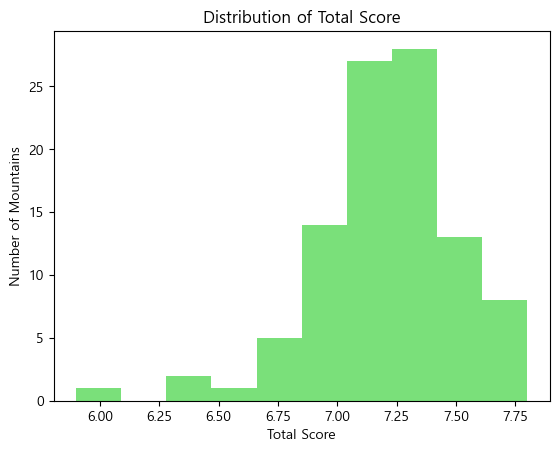

In [7]:
plt.figure()
plt.hist(mountain_avg_df["total_score"].dropna(), bins=10, color = '#7ae07a')
plt.title("Distribution of Total Score")
plt.xlabel("Total Score")
plt.ylabel("Number of Mountains")
plt.show()
